## Contribution
We first propose, rather than using a different PINN for each solution, to build an unique one that takes $y_0$ and $t$ as input. Then, we further assess the learning success by comparing the phase portrait of the PINN. Finally, we evaluate if the divergence of those systems can be used as an additional constraint for the PINN learning.

In [1]:
%loadlibs
from scipy.integrate import solve_ivp
import pandas as pd
import seaborn as sns
device = 'mps'
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


In [2]:
n_epochs = 5000
n_points = 2000
n_experiments = 10

## Pendulum
We start by generating simulated dataset.

In [3]:
l = 1.0
g = 9.81
T_MAX = 3.0
n_t = 512

def pendule(t, y, g, l):
    theta, theta_dot = y
    dtheta_dt = theta_dot
    dtheta_dot_dt = -(g / l) * np.sin(theta)
    return [dtheta_dt, dtheta_dot_dt]

res = {'y0': [], 't': [], 'y': []}
y_dot0 = 0.0
t_span = (0, T_MAX)
t_eval = np.linspace(*t_span, n_t)
for y0 in np.linspace(-np.pi, np.pi, 361):
    y, y_dot = solve_ivp(pendule, t_span, [y0, y_dot0], args=(g, l), t_eval=t_eval).y
    res['y0'].extend(np.ones(n_t) * y0)
    res['t'].extend(t_eval)
    res['y'].extend(y)
res['y0'] = np.array(res['y0'])
res['t'] = np.array(res['t'])
res['y'] = np.array(res['y'])
df_pendulum = pd.DataFrame(res)

Next, we design the PINN, with two inputs: $y_0, t$.

In [4]:
class PendulumPINN(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.l1 = nn.Linear(2, hidden)
        self.layers = nn.ModuleList([nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh(),
                                     nn.Linear(hidden, hidden), 
                                     nn.Tanh()])
        self.l3 = nn.Linear(hidden, 1)
        
    def forward(self, y0, t):
        inp = torch.cat([y0, t], dim=1)
        h = self.l1(inp)
        for layer in self.layers:
            h = layer(h)
        nn_out = self.l3(h)
        return (nn_out * t**2 + y0)

def physics_loss(model, y0, t):
    t = t.clone().requires_grad_(True)
    theta = model(y0, t)
    theta_t = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta), create_graph=True, retain_graph=True)[0]
    theta_tt = torch.autograd.grad(theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True, retain_graph=True)[0]
    residual = theta_tt + (g / l) * torch.sin(theta)
    p = torch.mean(residual ** 2)
    return p

def train_models(loss_fn):
    torch.random.manual_seed(0)
    errors_pendulum = np.zeros(len(df_pendulum['y0'].unique()))
    models_pendulum = [PendulumPINN() for n in range(n_experiments)]
    for n in tqdm(range(n_experiments)):
        model = models_pendulum[n]
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, min_lr=1e-5)
        
        for _ in (pbar := tqdm(range(n_epochs))):
            optimizer.zero_grad()
            t = torch.rand((n_points, 1)) * T_MAX
            y0 = (torch.rand((n_points, 1))-0.5) * 4 * torch.pi
            loss = loss_fn(model, y0, t)
            pbar.set_description(f"Loss:{loss.item():.4e}")
            loss.backward()
            optimizer.step()
            scheduler.step(loss.item())
        
        for i in range(len(errors_pendulum)):
            y0 = df_pendulum['y0'].unique()[i]
            simulation = df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy()
            y_hat = model(torch.ones(n_t, 1) * y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().squeeze().detach().numpy()
            errors_pendulum[i] += np.mean((y_hat-simulation)**2)
    return models_pendulum, errors_pendulum

In [5]:
def plot_phase(models_pendulum, idx=0):
    model = models_pendulum[idx].eval()
    n_t = 512
    
    y0_grid = np.linspace(-np.pi, np.pi, 361)
    t_eval = np.linspace(0, T_MAX, n_t)
    
    Y0, T = np.meshgrid(y0_grid, t_eval, indexing="ij")
    
    y0_flat = torch.tensor(Y0.reshape(-1, 1), dtype=torch.float32, device=device)
    t_flat  = torch.tensor(T.reshape(-1, 1),  dtype=torch.float32, device=device)
    
    with torch.no_grad():
        y_pred_flat = model(y0_flat, t_flat).cpu().numpy().reshape(-1)
    
    res_pinn = {
        'y0': Y0.reshape(-1),
        't':  T.reshape(-1),
        'y':  y_pred_flat,
    }
    df_pinn = pd.DataFrame(res_pinn)
    
    grid_true = df_pendulum.pivot(index='y0', columns='t', values='y').values
    grid_pred = df_pinn.pivot(index='y0', columns='t', values='y').values
    
    y0_axis = np.sort(df_pendulum['y0'].unique())
    t_axis  = np.sort(df_pendulum['t'].unique())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    vmin, vmax = -np.pi, np.pi
    levels = [-2.0, -1.0, 0.0, 1.0, 2.0]
    
    for ax, grid, title in zip(axes[:2], [grid_true, grid_pred], ["Ground truth (solve_ivp)", "PINN"]):
        pcm = ax.pcolormesh(t_axis, y0_axis, grid, shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
        cs = ax.contour(t_axis, y0_axis, grid, levels=levels, colors="k", linewidths=0.8)
        ax.clabel(cs, fmt="%.1f", fontsize=7)
        ax.set_xlabel("t")
        ax.set_title(title)
        
    fig.colorbar(pcm, ax=axes[1], label="theta")
    fig.colorbar(pcm, ax=axes[0], label="theta")
    axes[0].set_ylabel("y0 (initial condition)")
    
    diff = np.abs(grid_pred - grid_true)
    pcm2 = axes[2].pcolormesh(t_axis, y0_axis, diff, shading="auto", cmap="viridis")
    fig.colorbar(pcm2, ax=axes[2], label="|PINN - true|")
    axes[2].set_xlabel("t")
    axes[2].set_title(f"Absolute error (max={diff.max():.3f}, mean={diff.mean():.3f})")
    
    plt.tight_layout()
    plt.show()

To be able to compare with the original paper, we check the $\mathcal{L}^2$ norm for each IC.

In [6]:
def compute_errors(models):
    y0_array = df_pendulum['y0'].unique()
    all_errors = []
    for model_idx, model in enumerate(models):
        errors = []
        for y0 in y0_array:
            simulation = (df_pendulum[df_pendulum['y0'] == y0]['y'].to_numpy())
            y_hat = model(torch.ones_like(torch.tensor(t_eval, dtype=torch.float32)).unsqueeze(-1) * y0, torch.tensor(t_eval, dtype=torch.float32).unsqueeze(-1)).cpu().detach().squeeze().numpy()
            rel_l2 = (np.sqrt(np.sum((simulation - y_hat) ** 2)) / (1e-6 + np.sqrt(np.sum(simulation ** 2))))
            errors.append(rel_l2)
        errors = np.array(errors)
        all_errors.append(errors)
        #print(f"Model {model_idx}:", f"mean={errors.mean():.4f},", f"median={np.median(errors):.4f},", f"success_rate={(errors < 0.15).mean():.3f}")
    all_errors = np.array(all_errors)
    #plt.figure(figsize=(10, 7))
    #plt.boxplot(all_errors.T, showfliers=False)
    #plt.xlabel("Model")
    #plt.ylabel("Relative L2 Error")
    #plt.title("Error Distribution Across Experiments")
    #plt.grid()
    #plt.show()
    return all_errors

## Adding Energy as an Information 

In [7]:
def energy_loss(model, y0, t):
    t = t.clone().requires_grad_(True)
    theta = model(y0, t)
    E = 0.5*theta_t**2 - (g/l)*torch.cos(theta)
    E0 = -(g/l)*torch.cos(y0)
    l = torch.mean((E - E0)**2)
    return l

## Symmetry Information

In [8]:
def symmetry_theta_loss(model, y0, t):
    t = t.clone().requires_grad_(True)
    s = ((model(y0,t) + model(-y0,t))**2).mean()
    return s

## Time Symmetry

In [9]:
def symmetry_t_loss(model, y0, t):
    t = t.clone().requires_grad_(True)
    l = ((model(y0,t) - model(y0,-t))**2).mean()
    return l

## gPINN
We can differentiate the residual wrt. time and IC, and this gradient of the residual should be null everywhere.

In [10]:
def gpinn_loss(model, y0, t):
    t = t.clone().requires_grad_(True)
    theta = model(y0, t)
    theta_t = torch.autograd.grad(theta, t, grad_outputs=torch.ones_like(theta), create_graph=True, retain_graph=True)[0]
    theta_tt = torch.autograd.grad(theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True, retain_graph=True)[0]
    gpinn_term = (theta_tt + (g/l) * torch.sin(theta))
    gpinn_loss = ((torch.autograd.grad(gpinn_term, t, grad_outputs=torch.ones_like(t), create_graph=True, retain_graph=True)[0])**2).mean()
    return gpinn_loss

## Results

In [11]:
loss_functions = {"Physics": physics_loss, 
                  "Theta Symmetry": symmetry_theta_loss,
                  "Time Symmetry": symmetry_t_loss,
                  "gPINN": gpinn_loss}

In [12]:
from itertools import combinations
results = {}

for r in range(1, len(loss_functions) + 1):
    for combo in combinations(loss_functions.items(), r):
        names = [name for name, _ in combo]
        def combined_loss(*args, losses=[fn for _, fn in combo]):
            return sum(loss(*args) for loss in losses)
        models, errors = train_models(combined_loss)
        results[tuple(names)] = (models, errors)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

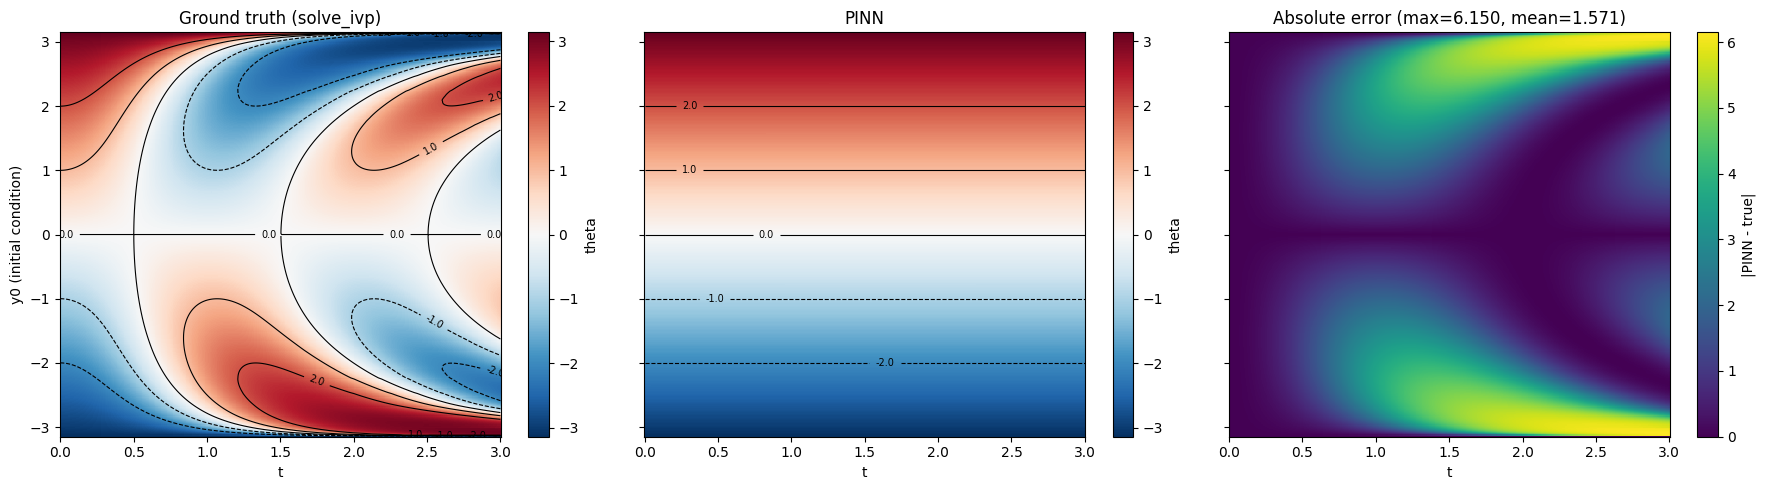

In [39]:
plot_phase(results[("Theta Symmetry", "Time Symmetry", "gPINN")][0])

In [21]:
errors = pd.DataFrame({" ".join(i): compute_errors(results[i][0])[1] for i in tqdm(results)})
errors = errors[errors.mean().sort_values(ascending=False).index]

  0%|          | 0/15 [00:00<?, ?it/s]

In [38]:
errors.median()

Time Symmetry                                 1.654076
Physics gPINN                                 0.986238
Physics Time Symmetry                         0.395858
Physics Theta Symmetry gPINN                  0.921995
Physics Time Symmetry gPINN                   0.918240
Physics Theta Symmetry                        0.417863
Physics Theta Symmetry Time Symmetry          0.487951
Physics Theta Symmetry Time Symmetry gPINN    0.898501
Physics                                       0.438487
gPINN                                         1.691174
Time Symmetry gPINN                           1.691066
Theta Symmetry gPINN                          1.691253
Theta Symmetry Time Symmetry gPINN            1.691118
Theta Symmetry                                1.682186
Theta Symmetry Time Symmetry                  1.683178
dtype: float64

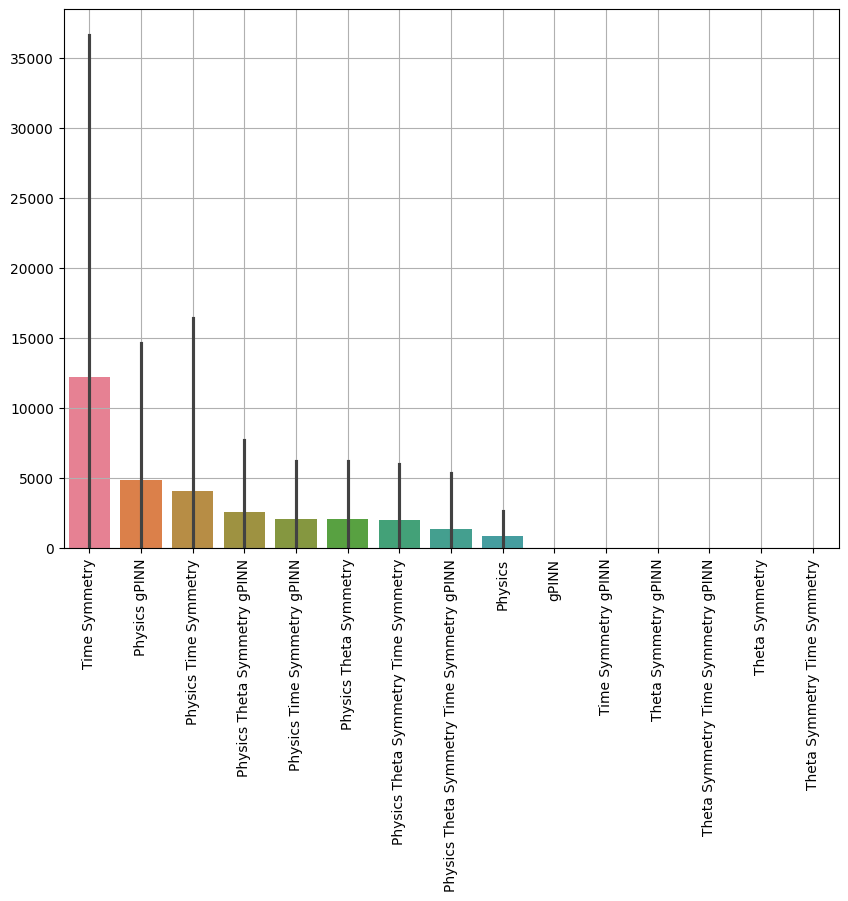

In [23]:
plt.figure(figsize=(10, 7))
sns.barplot(errors)
plt.xticks(rotation=90)
plt.grid()
plt.show()

# On the Role of Fixed Points of Dynamical Systems in Training Physics-Informed Neural Networks

## Introduction
The first part of this paper (2023 - Transaction on Machine Learning Research) present the impact of asymptotically stable, stable and unstable fixed points in two simple dynamical systems described by ODEs:
- An undamped pendulum: $\ddot{y} = \mathcal{F}[y] := - \frac{g}{l} \sin(y)$, where $y$ is the angle of the pendulum with the vertical, and $l=1.0$ and $g=9.81$ are the pendulum length and the graviational constant. No IC is hard-encoded.
- A toy example: $\dot{y} = \mathcal{F}[y] := y(1-y^2)$. Explicit IC is encoded by setting $\hat{y}(t) = y_0 + t y_{\theta}(t)$, where $y_{\theta}(t)$ is the output of the MLP.

In both cases, they evaluate the _learning success_ of PINN's by comparing their predictions with the solutions made using fourth order Runge-Kutta, considering the learning a success if the relative $L^2$ norm between the predicted trajectory and the expected one is below $15\%$. Each solution yielded by a new IC is approximated with a different PINN.

They show that IC close to fixed points and longer simulation times lead to lower success rate. The first is their initial hypothesis.

## Symmetry Information

## Time Symmetry

## gPINN
We can differentiate the residual wrt. time and IC, and this gradient of the residual should be null everywhere.

## Results